# 145 후속 — 마스킹 학습 LightGBM 비교 (`w2024`)

수치 원본은 같은 폴더의 `RESULTS.md`이고, 어긋나면 그쪽이 맞다. 이 노트북은
`compare.py --window w2024`가 남긴 `masking_check_*.parquet`을 **그림으로만** 다시 읽는다 —
GPU도 재계산도 필요 없다.

| 축 | 값 |
| --- | --- |
| 계열 | `lookup` · `lightgbm`(현행 배포) · `lgbm_masked_*`(마스킹 학습 후보) · `gru_s42/43/44` |
| 가용성 | `full` · `d7_only` · `d1_only` · `no_lag` |
| 비교 | 표 A(lookup 대비) · 표 B(LightGBM 쌍차이) · 표 B2(마스킹 후보 대 GRU 기준 쌍차이) |

In [1]:
import sys
from pathlib import Path

AI_ROOT = Path.cwd()
while not (AI_ROOT / "app" / "CROWD").exists():
    AI_ROOT = AI_ROOT.parent
sys.path.insert(0, str(AI_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from DATA_ENGINE.eda import figstyle

figstyle.apply(inline=True)

WINDOW = "w2024"
VAL = AI_ROOT / "data" / "CROWD" / "interim" / "validation" / "masking_check" / WINDOW


def _read(name):
    p = VAL / f"masking_check_{name}.parquet"
    return pd.read_parquet(p) if p.exists() else None


a = _read("A_lookup_대비_개선율_CI")
b = _read("B_lightgbm_쌍차이")
b2 = _read("B2_masked_GRU쌍차이")
c = _read("C_발산처리_적용행")

TARGETS = ["boarding", "alighting"]
KOR = {"boarding": "승차", "alighting": "하차"}
ORDER = ["full", "d7_only", "d1_only", "no_lag"]

tot_a = a[a["axis"] == "전체"]
tot_b = b[b["axis"] == "전체"]
tot_b2 = b2[b2["axis"] == "전체"] if b2 is not None else None
SC = sorted(tot_a["scenario"].unique(), key=lambda s: ORDER.index(s))
xx = np.arange(len(SC))
MASKED = sorted(n for n in tot_a["series"].unique() if n.startswith("lgbm_masked_"))

print(f"윈도우: {WINDOW} · 실행 커밋: {tot_a['git_commit'].iloc[0] if len(tot_a) else '?'}")
print(f"마스킹 후보: {MASKED} · 시나리오: {SC}")
if c is not None:
    print(f"발산 처리: {c['mode'].unique()[0]} · 상한 초과 행 합계 {int(c['상한초과_행'].sum())}")

윈도우: w2024 · 실행 커밋: c77df2d
마스킹 후보: ['lgbm_masked_replace', 'lgbm_masked_stack', 'lgbm_masked_stack_d1'] · 시나리오: ['full', 'd7_only', 'd1_only', 'no_lag']
발산 처리: raw · 상한 초과 행 합계 0


## 1. 가용성 시나리오별 lookup 대비 개선율 — LightGBM vs 마스킹 후보

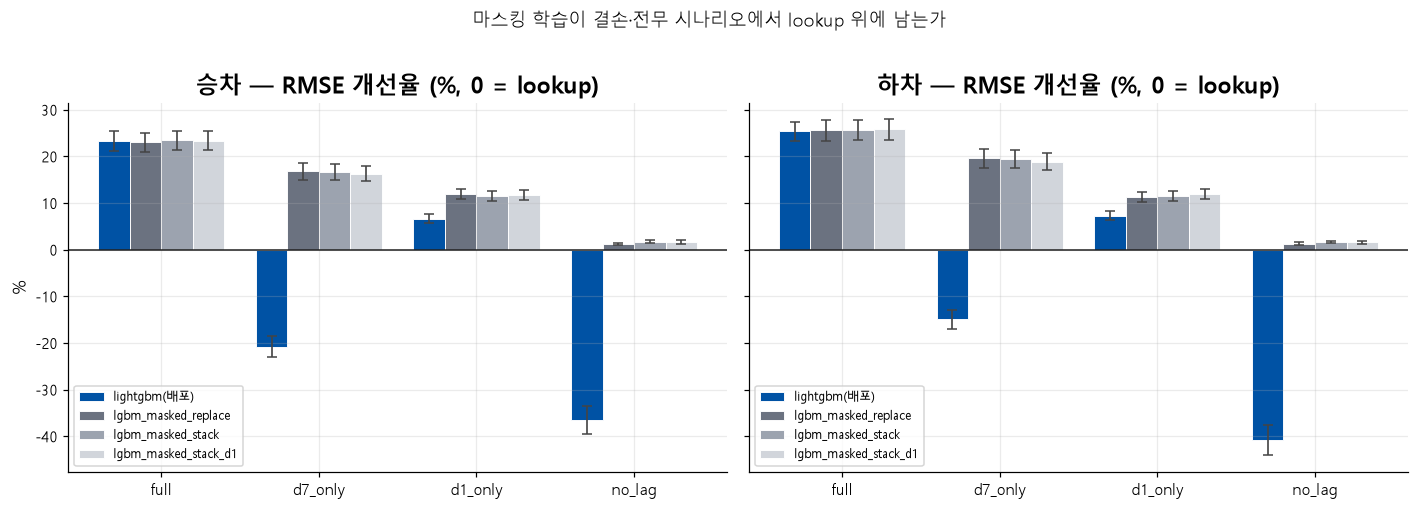

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
width = 0.8 / (1 + len(MASKED))

for ax, t in zip(axes, TARGETS):
    lgb = tot_a[(tot_a["series"] == "lightgbm") & (tot_a["target"] == t)].set_index("scenario")
    lgb = lgb.reindex(SC)
    point = lgb["RMSE_개선율_%"].to_numpy()
    err = [point - lgb["RMSE_CI_low"].to_numpy(), lgb["RMSE_CI_high"].to_numpy() - point]
    ax.bar(xx - 0.4 + width / 2, point, width, yerr=err, capsize=3, label="lightgbm(배포)",
           color=figstyle.COLOR_MODEL, edgecolor="white", linewidth=0.6,
           error_kw={"ecolor": "#444", "elinewidth": 1.1})
    for i, name in enumerate(MASKED, start=1):
        sub = tot_a[(tot_a["series"] == name) & (tot_a["target"] == t)].set_index("scenario")
        sub = sub.reindex(SC)
        pt = sub["RMSE_개선율_%"].to_numpy()
        e = [pt - sub["RMSE_CI_low"].to_numpy(), sub["RMSE_CI_high"].to_numpy() - pt]
        ax.bar(xx - 0.4 + width * (i + 0.5), pt, width, yerr=e, capsize=3, label=name,
               color=figstyle.PALETTE_NEUTRAL[i % len(figstyle.PALETTE_NEUTRAL)],
               edgecolor="white", linewidth=0.6, error_kw={"ecolor": "#444", "elinewidth": 1.1})
    ax.axhline(0, color="#222", linewidth=1.0)
    ax.set_xticks(xx)
    ax.set_xticklabels(SC)
    ax.set_title(f"{KOR[t]} — RMSE 개선율 (%, 0 = lookup)")
    ax.legend(fontsize=8, loc="lower left")
axes[0].set_ylabel("%")
fig.suptitle("마스킹 학습이 결손·전무 시나리오에서 lookup 위에 남는가", y=1.02)
fig.tight_layout()
_ = figstyle.save(fig, f"masking_scenarios_{WINDOW}")

## 2. 마스킹 후보 − LightGBM 쌍 차이 [95% CI]

`full`에서 현행 배포 대비 얼마나 밀리는지(채택 기준 2), 결손·전무에서 얼마나 따라잡는지를
같은 재표본으로 본다.

                               point_diff_RMSE_%p(계열-LightGBM)  diff_RMSE_CI_low  diff_RMSE_CI_high
series               scenario                                                                      
lgbm_masked_stack    full                                 0.04             -0.20               0.27
lgbm_masked_replace  full                                -0.39             -1.27               0.27
lgbm_masked_stack_d1 full                                -0.02             -0.25               0.18
gru_s42              full                                -2.92             -4.42              -1.20
gru_s43              full                                -3.55             -5.05              -1.81
gru_s44              full                                -3.17             -4.50              -1.43
lgbm_masked_stack    d7_only                             37.45             34.11              40.86
lgbm_masked_replace  d7_only                             37.64             34.12              41.25


C:\Users\SSAFY\AppData\Local\Temp\ipykernel_36204\4156324331.py:19: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.tight_layout()
C:\Users\SSAFY\miniforge3\envs\SUMGIL\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


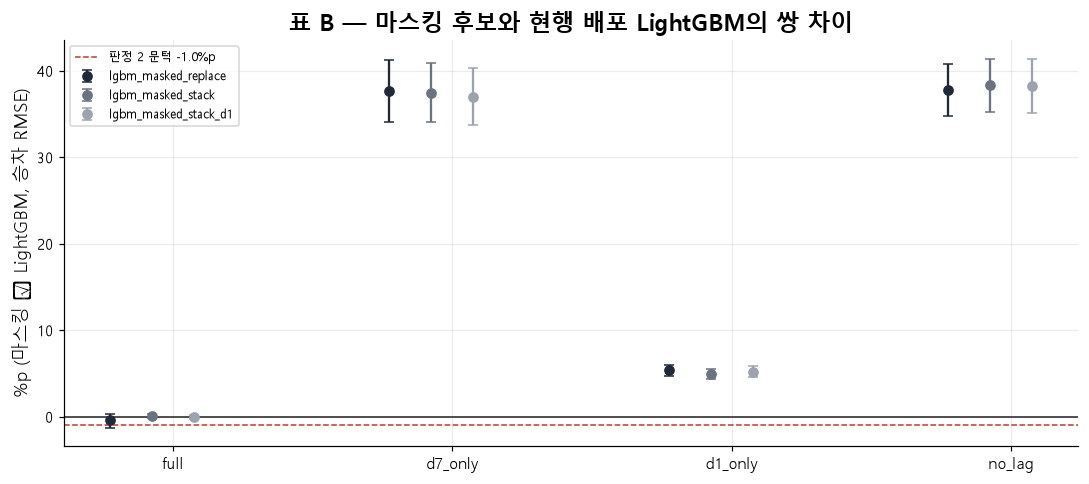

In [3]:
DIFF_R = next(col for col in tot_b.columns if col.startswith("point_diff_RMSE_%p"))

fig, ax = plt.subplots(figsize=(10, 4.5))
for i, name in enumerate(MASKED):
    sub = tot_b[(tot_b["series"] == name) & (tot_b["target"] == "boarding")]
    sub = sub.set_index("scenario").reindex(SC)
    point = sub[DIFF_R].to_numpy()
    lo = point - sub["diff_RMSE_CI_low"].to_numpy()
    hi = sub["diff_RMSE_CI_high"].to_numpy() - point
    ax.errorbar(xx + (i - len(MASKED) / 2) * 0.15, point, yerr=[lo, hi], fmt="o", capsize=3,
                label=name, color=figstyle.PALETTE_NEUTRAL[i % len(figstyle.PALETTE_NEUTRAL)])
ax.axhline(0, color="#222", linewidth=1.0)
ax.axhline(-1.0, color="#C0392B", linewidth=1.0, linestyle="--", label="판정 2 문턱 -1.0%p")
ax.set_xticks(xx)
ax.set_xticklabels(SC)
ax.set_ylabel("%p (마스킹 − LightGBM, 승차 RMSE)")
ax.set_title("표 B — 마스킹 후보와 현행 배포 LightGBM의 쌍 차이")
ax.legend(fontsize=8)
fig.tight_layout()
_ = figstyle.save(fig, f"masking_paired_diff_lightgbm_{WINDOW}")

print(tot_b[tot_b["target"] == "boarding"].set_index(["series", "scenario"])[
    [DIFF_R, "diff_RMSE_CI_low", "diff_RMSE_CI_high"]
].round(2).to_string())

## 3. 마스킹 후보 − GRU 기준 쌍 차이 [95% CI]

결손·전무 시나리오에서 GRU를 대체할 근거(채택 기준 3)가 있는지를 같은 방식으로 본다.

C:\Users\SSAFY\AppData\Local\Temp\ipykernel_36204\1649525530.py:22: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.tight_layout()


                               point_diff_RMSE_%p(계열-gru_s42)  diff_RMSE_CI_low  diff_RMSE_CI_high
series               scenario                                                                     
lgbm_masked_stack    full                                2.96              1.19               4.42
lgbm_masked_replace  full                                2.53              0.63               4.12
lgbm_masked_stack_d1 full                                2.90              1.16               4.37
lgbm_masked_stack    d7_only                            11.95              9.60              14.08
lgbm_masked_replace  d7_only                            12.14              9.64              14.45
lgbm_masked_stack_d1 d7_only                            11.50              9.18              13.64
lgbm_masked_stack    d1_only                            -5.59             -7.28              -4.15
lgbm_masked_replace  d1_only                            -5.22             -6.90              -3.78
lgbm_maske

C:\Users\SSAFY\miniforge3\envs\SUMGIL\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


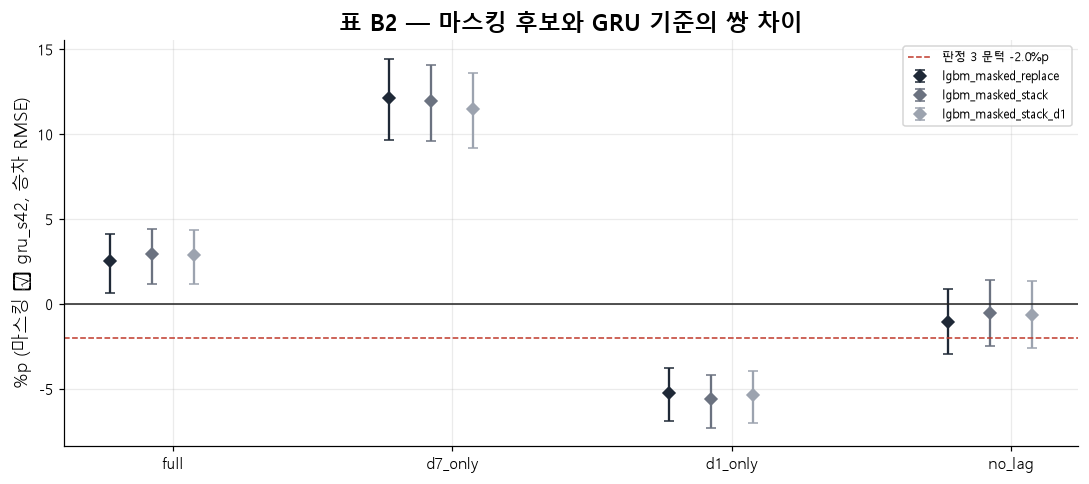

In [4]:
if tot_b2 is None:
    print("표 B2 없음 — compare.py가 아직 안 돌았다")
else:
    diff_r2 = next(col for col in tot_b2.columns if col.startswith("point_diff_RMSE_%p"))
    gru_label = diff_r2.split("계열-")[-1].rstrip(")")
    fig, ax = plt.subplots(figsize=(10, 4.5))
    for i, name in enumerate(MASKED):
        sub = tot_b2[(tot_b2["series"] == name) & (tot_b2["target"] == "boarding")]
        sub = sub.set_index("scenario").reindex(SC)
        point = sub[diff_r2].to_numpy()
        lo = point - sub["diff_RMSE_CI_low"].to_numpy()
        hi = sub["diff_RMSE_CI_high"].to_numpy() - point
        ax.errorbar(xx + (i - len(MASKED) / 2) * 0.15, point, yerr=[lo, hi], fmt="D", capsize=3,
                    label=name, color=figstyle.PALETTE_NEUTRAL[i % len(figstyle.PALETTE_NEUTRAL)])
    ax.axhline(0, color="#222", linewidth=1.0)
    ax.axhline(-2.0, color="#C0392B", linewidth=1.0, linestyle="--", label="판정 3 문턱 -2.0%p")
    ax.set_xticks(xx)
    ax.set_xticklabels(SC)
    ax.set_ylabel(f"%p (마스킹 − {gru_label}, 승차 RMSE)")
    ax.set_title("표 B2 — 마스킹 후보와 GRU 기준의 쌍 차이")
    ax.legend(fontsize=8)
    fig.tight_layout()
    _ = figstyle.save(fig, f"masking_paired_diff_gru_{WINDOW}")

    print(tot_b2[tot_b2["target"] == "boarding"].set_index(["series", "scenario"])[
        [diff_r2, "diff_RMSE_CI_low", "diff_RMSE_CI_high"]
    ].round(2).to_string())

## 4. 읽는 법

- **1절**은 채택 기준 1(결손·전무에서 lookup 대비 CI 하한 > 0)을 눈으로 확인한다.
- **2절**은 채택 기준 2(`full`에서 −1.0%p 이내, CI 상한 ≥ 0)를 본다 — 점선을 밑돌면 `full` 성능을
  포기한 것이다.
- **3절**은 채택 기준 3(결손·전무에서 GRU와 동등 이상, −2%p 이내)을 본다.
- 채택 기준 4(방향이 다른 기간 윈도우에서도 유지)는 이 노트북이 답하지 않는다 — `--window w2023`
  등으로 따로 실행한 노트북과 나란히 봐야 한다.